In [1]:
import os, pathlib
import pandas as pd

df = pd.read_csv("./CEAS_08.csv")
# df.head()



# Take a subset of the dataset (20% of each label)
df_label_0 = df[df['label'] == 0].sample(frac=0.006, random_state=42)
df_label_1= df[df['label'] == 1].sample(frac=0.006, random_state=42)

df = pd.concat([df_label_0, df_label_1]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"New dataset size: {len(df)}")
print("Distribution of labels in the subset:")
print(df['label'].value_counts())


New dataset size: 235
Distribution of labels in the subset:
label
1    131
0    104
Name: count, dtype: int64


Imports & Setup

In [2]:
from __future__ import annotations
import os
import gc
from dataclasses import dataclass
from typing import List, Tuple, Optional

import pandas as pd
import torch
from torch.utils.data import Dataset as TorchDataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    set_seed,
)

from datetime import datetime
from tqdm import tqdm


2025-10-01 02:29:15.041128: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759264155.068897 1157089 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759264155.077449 1157089 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1759264155.104755 1157089 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1759264155.104795 1157089 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1759264155.104797 1157089 computation_placer.cc:177] computation placer alr

GPU Sanity Check

In [3]:
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("Device name:", torch.cuda.get_device_name(0))

Torch version: 2.8.0+cu128
CUDA available: True
Device count: 1
Device name: NVIDIA GeForce RTX 4060 Ti


Log Message Utility

In [4]:
# ----------------------------
# Simple Logging Utility
# ----------------------------
from datetime import datetime

def log_message(save_dir: str, msg: str, console: bool = True):
    log_path = os.path.join(save_dir, "training_log.txt")
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    line = f"[{timestamp}] {msg}\n"
    with open(log_path, "a") as f:
        f.write(line)
    if console:
        print(line, end="")

Dataset Utilities

In [5]:
@dataclass
class EncodedBatch:
    input_ids: torch.Tensor
    attention_mask: torch.Tensor
    labels: torch.Tensor


class TextClassificationDataset(TorchDataset):
    def __init__(self, texts: List[str], labels: List[int], tokenizer, max_length: int = 256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])
        enc = self.tokenizer(
            text,
            truncation=True,
            padding=False,
            max_length=self.max_length,
            return_tensors="pt",
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels"] = torch.tensor(label, dtype=torch.long)
        return item

albert-based classifier

In [6]:
def train_discriminator(
    train_df: pd.DataFrame,
    save_dir: str = "./albert_game_model",
    model_name: str = "albert-base-v2",
    max_length: int = 256,
    train_batch_size: int = 16,
    learning_rate: float = 5e-5,
    num_train_epochs: int = 3,
    gradient_accumulation_steps: int = 1,
    fp16: bool = True,
    weight_decay: float = 0.01,
    logging_steps: int = 1,
    seed: int = 42,
    round_id: Optional[int] = None,
):
    """
    Train a PyTorch ALBERT classifier on the given training set.
    Skips training if a model already exists in `save_dir`.
    Returns: (model, tokenizer)
    """
    assert {"body", "label"}.issubset(train_df.columns)
    model_save_dir = os.path.join(save_dir, "model")    
    os.makedirs(model_save_dir, exist_ok=True)
    set_seed(seed)

    round_tag = f"[Round {round_id}]" if round_id else "[Discriminator]"

    # Skip training if model already exists
    model_file = os.path.join(model_save_dir, "model.safetensors")
    config_file = os.path.join(model_save_dir, "config.json")
    if os.path.exists(model_file) and os.path.exists(config_file):
        tokenizer = AutoTokenizer.from_pretrained(model_save_dir)
        model = AutoModelForSequenceClassification.from_pretrained(model_save_dir)
        log_message(save_dir, f"{round_tag} Found existing model in {model_save_dir}. Skipping training.")
        return model, tokenizer

    # Default: Load tokenizer & model
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    num_labels = int(pd.Series(train_df["label"]).nunique())
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)

    # Dataset
    train_ds = TextClassificationDataset(
        train_df["body"].astype(str).tolist(),
        train_df["label"].astype(int).tolist(),
        tokenizer,
        max_length,
    )

    # Training args (no eval set)
    args = TrainingArguments(
        output_dir=save_dir,
        per_device_train_batch_size=train_batch_size,
        learning_rate=learning_rate,
        num_train_epochs=num_train_epochs,
        gradient_accumulation_steps=gradient_accumulation_steps,
        fp16=fp16,
        weight_decay=weight_decay,
        logging_steps=logging_steps,
        save_strategy="epoch",
        save_total_limit=2,
        report_to=[],
        logging_strategy="steps",
        logging_dir=os.path.join(save_dir, "runs"),
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        tokenizer=tokenizer,
    )

    log_message(save_dir, f"{round_tag} Starting training...")
    trainer.train()

    trainer.save_model(model_save_dir)
    tokenizer.save_pretrained(model_save_dir)
    log_message(model_save_dir, f"{round_tag} Training completed. Model saved to {model_save_dir}")

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return model, tokenizer

adversarial sample generation (TextAttack)

In [7]:
from textattack.models.wrappers import HuggingFaceModelWrapper
from textattack.datasets import Dataset as TADataset
from textattack import AttackArgs, Attacker
from textattack.shared.checkpoint import AttackCheckpoint
from textattack.attack_recipes import TextFoolerJin2019, PWWSRen2019, DeepWordBugGao2018
from textattack.attack_results import SuccessfulAttackResult, FailedAttackResult, SkippedAttackResult
from transformers import AutoTokenizer, AutoModelForSequenceClassification

dummy_model_name = "albert-base-v2"  # Small and fast to load
dummy_tokenizer = AutoTokenizer.from_pretrained(dummy_model_name)
dummy_model = AutoModelForSequenceClassification.from_pretrained(dummy_model_name, num_labels=2)

# Create a wrapper
dummy_wrapper = HuggingFaceModelWrapper(dummy_model, dummy_tokenizer)

# 2. Build attack recipes to download embeddings and data
print("Downloading TextAttack resources...")
for recipe_class in [TextFoolerJin2019, PWWSRen2019, DeepWordBugGao2018]:
    try:
        print(f"Downloading resources for {recipe_class.__name__}...")
        _ = recipe_class.build(dummy_wrapper)  # This will download required embeddings/data
        print(f"✓ {recipe_class.__name__} resources downloaded")
    except Exception as e:
        print(f"⚠ Could not download resources for {recipe_class.__name__}: {e}")

print("All TextAttack resources downloaded successfully!")

/home/nazmul/anaconda3/envs/nlp_game/lib/python3.12/site-packages/jieba/_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Some weights of AlbertForSequenceClassification were not initialized from the model checkpoint at albert-base-v2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


textattack: Unknown if model of class <class 'transformers.models.albert.modeling_albert.AlbertForSequenceClassification'> compatible with goal function <class 'textattack.goal_functions.classification.untargeted_classification.UntargetedClassification'>.


✓ TextFoolerJin2019 resources downloaded


[nltk_data] Downloading package omw-1.4 to /home/nazmul/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
textattack: Unknown if model of class <class 'transformers.models.albert.modeling_albert.AlbertForSequenceClassification'> compatible with goal function <class 'textattack.goal_functions.classification.untargeted_classification.UntargetedClassification'>.
textattack: Unknown if model of class <class 'transformers.models.albert.modeling_albert.AlbertForSequenceClassification'> compatible with goal function <class 'textattack.goal_functions.classification.untargeted_classification.UntargetedClassification'>.


✓ PWWSRen2019 resources downloaded
✓ DeepWordBugGao2018 resources downloaded
All TextAttack resources downloaded successfully!


In [8]:
# ----------------------------
# Adversarial Generation (TextAttack)
# ----------------------------
def generate_adversarial_samples(
    model: torch.nn.Module,
    tokenizer,
    dataset_df: pd.DataFrame,
    recipe: str = "textfooler",
    max_examples: Optional[int] = None,
    seed: int = 42,
) -> Tuple[pd.DataFrame, dict]:
    """Generate adversarial samples using TextAttack with a live progress bar."""

    assert {"body", "label"}.issubset(dataset_df.columns)

    set_seed(seed)
    tuples = [(str(row["body"]), int(row["label"])) for _, row in dataset_df.iterrows()]
    if max_examples is not None:
        tuples = tuples[: max(0, int(max_examples))]

    ta_dataset = TADataset(tuples)

    if torch.cuda.is_available():
        model.to("cuda")
    wrapper = HuggingFaceModelWrapper(model, tokenizer)
    if torch.cuda.is_available():
        wrapper.model.to("cuda")   # ensure TextAttack wrapper uses GPU

    if recipe == "textfooler":
        attack = TextFoolerJin2019.build(wrapper)
    elif recipe == "pwws":
        attack = PWWSRen2019.build(wrapper)
    elif recipe == "deepwordbug":
        attack = DeepWordBugGao2018.build(wrapper)
    else:
        raise ValueError(f"Unsupported recipe: {recipe}")

    attack_args = AttackArgs(
        disable_stdout=True,  # stops printing each sample
        num_examples=len(ta_dataset),
    )
    attacker = Attacker(attack, ta_dataset, attack_args=attack_args)

    adv_rows = []
    success, fail, skipped = 0, 0, 0
    total_queries_success = 0
    total_queries_failed = 0
    total_perturbed_word_pct = 0
    total_original_words = 0
    original_correct = 0
    attack_results = []

    print(f"Starting adversarial attack with {recipe} on {len(ta_dataset)} samples...")
    for result in tqdm(attacker.attack_dataset(), total=len(ta_dataset), ncols=100, desc=f"{recipe} attack"):
        attack_results.append(result)
        
        # Count original correct predictions
        if result.original_result.output == result.original_result.ground_truth_output:
            original_correct += 1
        
        # Count words for ALL samples (successful, failed, and skipped)
        original_text = result.original_result.attacked_text
        total_original_words += len(original_text.words)
        
        if isinstance(result, SuccessfulAttackResult):
            adv_text = result.perturbed_result.attacked_text.text
            original_label = int(result.original_result.ground_truth_output)
            adv_rows.append({"body": adv_text, "label": original_label})
            success += 1
            total_queries_success += result.num_queries
            
            # Calculate perturbed words percentage only for successful attacks
            perturbed_text = result.perturbed_result.attacked_text
            num_words_changed = len(original_text.all_words_diff(perturbed_text))
            perturbed_pct = (num_words_changed / len(original_text.words) * 100) if len(original_text.words) > 0 else 0
            total_perturbed_word_pct += perturbed_pct
            
        elif isinstance(result, FailedAttackResult):
            fail += 1
            total_queries_failed += result.num_queries
        elif isinstance(result, SkippedAttackResult):
            skipped += 1
        else:
            fail += 1

    # Calculate statistics
    total_attacks = len(attack_results)
    original_accuracy = (original_correct / total_attacks * 100) if total_attacks > 0 else 0
    accuracy_under_attack = (fail / total_attacks * 100) if total_attacks > 0 else 0
    attack_success_rate = (success / (success + fail) * 100) if (success + fail) > 0 else 0
    avg_perturbed_word_pct = (total_perturbed_word_pct / success) if success > 0 else 0
    avg_num_words = (total_original_words / total_attacks) if total_attacks > 0 else 0

    # FIXED: Calculate average queries differently - TextAttack might exclude skipped attacks
    total_attempted_attacks = success + fail
    total_queries_all = total_queries_success + total_queries_failed
    avg_queries = (total_queries_all / total_attempted_attacks) if total_attempted_attacks > 0 else 0

    # Create the summary table with proper formatting
    attack_summary = {
        "Number of successful attacks:": f"{success:<8}",
        "Number of failed attacks:": f"{fail:<8}",
        "Number of skipped attacks:": f"{skipped:<8}",
        "Original accuracy:": f"{original_accuracy:.2f}%".ljust(8),
        "Accuracy under attack:": f"{accuracy_under_attack:.2f}%".ljust(8),
        "Attack success rate:": f"{attack_success_rate:.2f}%".ljust(8),
        "Average perturbed word %:": f"{avg_perturbed_word_pct:.2f}%".ljust(8),
        "Average num. words per input:": f"{avg_num_words:.2f}".ljust(8),
        "Avg num queries:": f"{avg_queries:.2f}".ljust(8)
    }

    # # Print the table in TextAttack format
    # print("\n+-------------------------------+---------+")
    # print("| Attack Results                |         |")
    # print("+-------------------------------+---------+")
    # for key, value in attack_summary.items():
    #     print(f"| {key:<30} | {value} |")
    # print("+-------------------------------+---------+")

    stats_df = pd.DataFrame([{k.strip(':'): v.strip() for k, v in attack_summary.items()}])
    adv_df = pd.DataFrame(adv_rows, columns=["body", "label"]).dropna()

    print(f"\nFinished {recipe} attack: {success} success, {fail} fail, {skipped} skipped.")
    return adv_df, stats_df

multi-round adversarial training game

In [9]:
# ----------------------------
# Adversarial Training Game Loop
# ----------------------------

def adversarial_training_game(
    df: pd.DataFrame, #train pool only-->80%
    rounds: int = 5,
    save_dir: str = "./albert_game_model",
    adv_samples_per_round: Optional[int] = None,  # default = full dataset
    model_name: str = "albert-base-v2",
    max_length: int = 256,
    train_batch_size: int = 16,
    learning_rate: float = 5e-5,
    num_train_epochs: int = 3,
    gradient_accumulation_steps: int = 1,
    fp16: bool = True,
    weight_decay: float = 0.01,
    logging_steps: int = 50,
    seed: int = 42,
    resume_round: int = 1,
):
    os.makedirs(save_dir, exist_ok=True)
    assert {"body", "label"}.issubset(df.columns)
    df = df.copy()
    recipes = ["textfooler", "pwws", "deepwordbug"]
    
    if adv_samples_per_round is None:
          adv_samples_per_round = len(df)  # full train dataset

    # Initialize tokenizer and model once
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model_path = os.path.join(save_dir, "base_model")
    if resume_round == 1 or not os.path.exists(model_path):
        # Round 1 or no base model: initialize new model
        num_labels = int(pd.Series(df["label"].tolist()).nunique())
        model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)
        print(f"Initialized new ALBERT model with {num_labels} labels.")
    else:
        # Resume from previous round
        last_round_dir = os.path.join(save_dir, f"round_{resume_round - 1}", "model")
        if os.path.exists(last_round_dir):
            model = AutoModelForSequenceClassification.from_pretrained(last_round_dir)
            tokenizer = AutoTokenizer.from_pretrained(last_round_dir)
            print(f"Resuming from model of round {resume_round - 1} at {last_round_dir}")
        else:
            # Strict error: do NOT fallback
            raise FileNotFoundError(
                f"Cannot resume from round {resume_round - 1}: "
                f"model directory not found at {last_round_dir}"
            )

    # Main adversarial training loop
    for r in range(resume_round, rounds + 1):
        print(f"\n=== START ROUND {r} / {rounds} ===")
        print(f"Current dataset size: {len(df)}")
        log_message(save_dir, f"===== Round {r} / {rounds} =====")

        # Checkpoint directory for this round
        round_dir = os.path.join(save_dir, f"round_{r}")
        os.makedirs(round_dir, exist_ok=True)

        # Merge previous adversarial examples if resuming
        if r > 1:
            prev_adv_path = os.path.join(save_dir, f"round_{r-1}_augmented_dataset.csv")
            if os.path.exists(prev_adv_path):
                adv_prev = pd.read_csv(prev_adv_path)
                if not adv_prev.empty:
                    before = len(df)
                    df = pd.concat([df, adv_prev], ignore_index=True)
                    df.drop_duplicates(subset=["body"], inplace=True)
                    after = len(df)
                    print(f"Merged previous adversarial samples: dataset size {before} -> {after}")
                    log_message(save_dir, f"Resuming round {r}: dataset size {before} -> {after}")

        model, tokenizer = train_discriminator(
          train_df=df,                # renamed arg
          save_dir=round_dir,
          model_name=model_name,
          max_length=max_length,
          train_batch_size=train_batch_size,
          learning_rate=learning_rate,
          num_train_epochs=num_train_epochs,
          gradient_accumulation_steps=gradient_accumulation_steps,
          fp16=fp16,
          weight_decay=weight_decay,
          logging_steps=logging_steps,
          seed=seed,
          round_id=r,
      )

        # Save base model after first training round
        if r == 1:
            base_model_dir = os.path.join(save_dir, "base_model")
            model.save_pretrained(base_model_dir)
            tokenizer.save_pretrained(base_model_dir)
            print(f"Saved base model after round 1 to {base_model_dir}")

        adv_samples_per_round = len(df)  # full train dataset

        # Generate adversarial examples
        base_for_attack = df.sample(n=min(adv_samples_per_round*2, len(df)), random_state=seed).reset_index(drop=True)
        combined_adv = []
        for recipe in recipes:
          # Paths for full texts and stats
          adv_texts_path = os.path.join(round_dir, f"round_{r}_{recipe}_adversarial_texts.csv")
          stats_path = os.path.join(round_dir, f"round_{r}_{recipe}_stats.csv")

          # Check if the adversarial texts file already exists
          if os.path.exists(adv_texts_path):
              # Load previously saved results
              adv_df = pd.read_csv(adv_texts_path)
              stats_df = pd.read_csv(stats_path)
              stats = stats_df.to_dict(orient="records")[0]  # convert one-row DataFrame to dict
              print(f"Loaded existing results for {recipe} from {adv_texts_path}")
          else:
              # Run attack if file does not exist
              print(f"received adv_samples_per_round: ", adv_samples_per_round)
              adv_df, stats_df = generate_adversarial_samples(
                  model=model,
                  tokenizer=tokenizer,
                  dataset_df=base_for_attack,
                  max_examples=adv_samples_per_round,
                  recipe=recipe,
                  seed=seed,
              )
              # Save full adversarial texts
              adv_df.to_csv(adv_texts_path, index=False)
              print(f"Saved {len(adv_df)} successful adversarial samples to {adv_texts_path}")

              # Save just the stats
              stats_df.to_csv(stats_path, index=False)
              print(f"Saved stats to {stats_path}")

          # Keep track of combined adversarial examples
          if not adv_df.empty:
              combined_adv.append(adv_df)


        adv_df = pd.concat(combined_adv, ignore_index=True) if combined_adv else pd.DataFrame(columns=["body", "label"])
        print(f"Total adversarial samples collected this round: {len(adv_df)}")
        log_message(save_dir, f"Total adversarial samples collected this round: {len(adv_df)}")

        # Merge & dedupe dataset for next round
        if not adv_df.empty:
            before = len(df)
            df = pd.concat([df, adv_df], ignore_index=True)
            df.drop_duplicates(subset=["body"], inplace=True)
            after = len(df)
            print(f"Dataset size after merging adversarial samples: {before} -> {after}")
            log_message(save_dir, f"Dataset size after merge: {before} -> {after}")

        # Save combined adversarial set
        adv_path = os.path.join(save_dir, f"round_{r}_augmented_dataset.csv")
        adv_df.to_csv(adv_path, index=False)
        print(f"Saved combined adversarial set to {adv_path}")
        log_message(save_dir, f"Saved combined adversarial samples to {adv_path}")

        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        print(f"=== END ROUND {r} ===\n")

    return model, tokenizer, df

In [10]:
import nltk
nltk.download("averaged_perceptron_tagger_eng")
nltk.download("wordnet")   # also needed for synonyms
nltk.download("omw-1.4")   # WordNet dependencies

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/nazmul/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to /home/nazmul/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/nazmul/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

Begin Training GAME

In [11]:
from sklearn.model_selection import train_test_split

# Split once into train_pool (80%) and dev_set (20%)
train_pool, dev_set = train_test_split(
    df, test_size=0.2, stratify=df["label"], random_state=42
)

version = "v2"
save_dir = f"./albert_adversarial_game_model_{version}"
rounds = 3
val_save_dir = f"./albert_adversarial_val_sets_{version}"
os.makedirs(save_dir, exist_ok=True)
os.makedirs(val_save_dir, exist_ok=True)

In [12]:
if not os.path.exists(f"{val_save_dir}/augmented_validation_set_0.csv"):
    dev_set.to_csv(f"{val_save_dir}/augmented_validation_set_0.csv", index=False)
    print(f"Saved dev set to {val_save_dir}/augmented_validation_set_0.csv ({len(dev_set)} samples)")

In [13]:
final_model, final_tokenizer, final_dataset = adversarial_training_game(
        df=train_pool,
        rounds=rounds,
        save_dir=save_dir,
        model_name="albert-base-v2",
        max_length=256,
        train_batch_size=8,
        learning_rate=5e-5,
        num_train_epochs=3,
        gradient_accumulation_steps=1,
        fp16=True,
        weight_decay=0.01,
        logging_steps=5,
        seed=42,
)

Some weights of AlbertForSequenceClassification were not initialized from the model checkpoint at albert-base-v2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Initialized new ALBERT model with 2 labels.

=== START ROUND 1 / 3 ===
Current dataset size: 188
[2025-10-01 02:29:32] ===== Round 1 / 3 =====
[2025-10-01 02:29:32] [Round 1] Found existing model in ./albert_adversarial_game_model_v2/round_1/model. Skipping training.
Saved base model after round 1 to ./albert_adversarial_game_model_v2/base_model
Loaded existing results for textfooler from ./albert_adversarial_game_model_v2/round_1/round_1_textfooler_adversarial_texts.csv
Loaded existing results for pwws from ./albert_adversarial_game_model_v2/round_1/round_1_pwws_adversarial_texts.csv
Loaded existing results for deepwordbug from ./albert_adversarial_game_model_v2/round_1/round_1_deepwordbug_adversarial_texts.csv
Total adversarial samples collected this round: 56
[2025-10-01 02:29:32] Total adversarial samples collected this round: 56
Dataset size after merging adversarial samples: 188 -> 244
[2025-10-01 02:29:32] Dataset size after merge: 188 -> 244
Saved combined adversarial set to ./

In [14]:
# import tensorflow_hub as hub

# print("Downloading Universal Sentence Encoder...")
# model = hub.load("https://tfhub.dev/google/universal-sentence-encoder/4")
# print("Done. Model cached in default TFHub folder.")

In [15]:
recipes = ["textfooler", "pwws", "deepwordbug"]

for r in range(1, rounds + 1):
    model_dir = os.path.join(save_dir, f"round_{r}", "model")
    assert os.path.exists(model_dir), f"Model dir not found: {model_dir}"

    out_path = os.path.join(val_save_dir, f"augmented_validation_set_{r}.csv")
    if os.path.exists(out_path):
        print(f"Validation set already exists: {out_path}")
        continue

    print(f"\n====================== Round {r} ======================\n")

    # Load discriminator for this round
    tokenizer = AutoTokenizer.from_pretrained(model_dir)
    model = AutoModelForSequenceClassification.from_pretrained(model_dir)
    model.eval()
    if torch.cuda.is_available():
        model.to("cuda")

    adv_dfs = []

    for recipe_name in recipes:
        if os.path.exists(os.path.join(val_save_dir, f"{recipe_name}_val_set_round_{r}.csv")):
            print(f"Validation set already exists for {recipe_name}: {os.path.join(val_save_dir, f'{recipe_name}_val_set_round_{r}.csv')}")
            continue

        print(f"--> Running {recipe_name} attack on dev set")

        adv_df, stats = generate_adversarial_samples(
            model=model,
            tokenizer=tokenizer,
            dataset_df=dev_set,
            recipe=recipe_name,
            max_examples=None,  # or set a limit if needed
            seed=42,
        )

        adv_df_path = os.path.join(val_save_dir, f"{recipe_name}_val_set_round_{r}.csv")
        adv_df.to_csv(adv_df_path, index=False)
        adv_dfs.append(adv_df)

        print(f"[Round {r}][{recipe_name}] stats: {stats}")

    # Merge clean dev + all adversarial samples
    combined_df = pd.concat([dev_set] + adv_dfs, ignore_index=True)

    out_path = os.path.join(val_save_dir, f"augmented_validation_set_{r}.csv")
    combined_df.to_csv(out_path, index=False)

    print(f"\n[Round {r}] Saved augmented validation set with all recipes to {out_path}\n")

print("Finished generating adversarial validation sets for all rounds and recipes.")

Validation set already exists: ./albert_adversarial_val_sets_v2/augmented_validation_set_1.csv
Validation set already exists: ./albert_adversarial_val_sets_v2/augmented_validation_set_2.csv
Validation set already exists: ./albert_adversarial_val_sets_v2/augmented_validation_set_3.csv
Finished generating adversarial validation sets for all rounds and recipes.


all models and validation sets

In [16]:
rounds = 3  # for example
models = {}
val_sets = {}

# Load all models and validation sets
for r in range(1, rounds + 1):
    model_dir = os.path.join(save_dir, f"round_{r}", "model")
    val_path = os.path.join(val_save_dir, f"augmented_validation_set_{r}.csv")

    tokenizer = AutoTokenizer.from_pretrained(model_dir)
    model = AutoModelForSequenceClassification.from_pretrained(model_dir)
    model.eval()
    if torch.cuda.is_available():
        model.to("cuda")

    models[r] = (model, tokenizer)
    val_sets[r] = pd.read_csv(val_path)


evaluation function

In [17]:
from torch.utils.data import DataLoader, TensorDataset
import torch

def evaluate_model(model, tokenizer, df, max_length=256, batch_size=16):
    # Convert text to token IDs
    encodings = tokenizer(list(df["body"]), padding=True, truncation=True, max_length=max_length, return_tensors="pt")
    labels = torch.tensor(df["label"].values)

    dataset = TensorDataset(encodings["input_ids"], encodings["attention_mask"], labels)
    loader = DataLoader(dataset, batch_size=batch_size)

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for input_ids, attention_mask, batch_labels in loader:
            if torch.cuda.is_available():
                input_ids = input_ids.cuda()
                attention_mask = attention_mask.cuda()
                batch_labels = batch_labels.cuda()
            outputs = model(input_ids, attention_mask=attention_mask)
            preds = outputs.logits.argmax(dim=-1)
            correct += (preds == batch_labels).sum().item()
            total += batch_labels.size(0)
    return correct / total


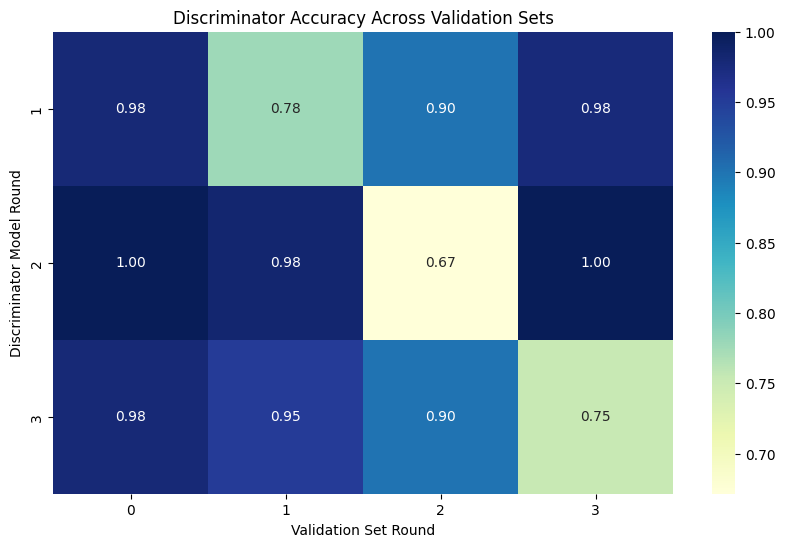

In [18]:
results = []
for model_round in range(1, rounds+1):
    model_dir = f"{save_dir}/round_{model_round}/model"
    tokenizer = AutoTokenizer.from_pretrained(model_dir)
    model = AutoModelForSequenceClassification.from_pretrained(model_dir)
    model.eval()
    if torch.cuda.is_available():
        model.to("cuda")
    
    for val_round in range(0, rounds+1):
        val_path = f"{val_save_dir}/augmented_validation_set_{val_round}.csv"
        val_df = pd.read_csv(val_path)
        acc = evaluate_model(model, tokenizer, val_df)  # your evaluation function
        results.append({
            "model_round": model_round,
            "val_round": val_round,
            "accuracy": acc
        })

results_df = pd.DataFrame(results)

import seaborn as sns
import matplotlib.pyplot as plt

heatmap_df = results_df.pivot(index="model_round", columns="val_round", values="accuracy")

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_df, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Discriminator Accuracy Across Validation Sets")
plt.xlabel("Validation Set Round")
plt.ylabel("Discriminator Model Round")
plt.show()

Before dropping duplicates: (63, 7)
After dropping duplicates: (16, 7)
Before dropping duplicates: (70, 7)
After dropping duplicates: (23, 7)
Before dropping duplicates: (85, 7)
After dropping duplicates: (38, 7)
Before dropping duplicates: (63, 7)
After dropping duplicates: (16, 7)
Before dropping duplicates: (70, 7)
After dropping duplicates: (23, 7)
Before dropping duplicates: (85, 7)
After dropping duplicates: (38, 7)
Before dropping duplicates: (63, 7)
After dropping duplicates: (16, 7)
Before dropping duplicates: (70, 7)
After dropping duplicates: (23, 7)
Before dropping duplicates: (85, 7)
After dropping duplicates: (38, 7)


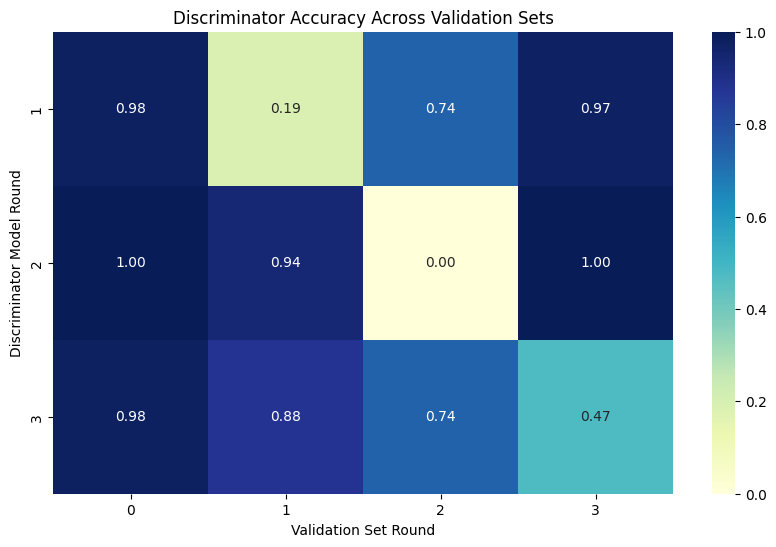

In [19]:
# results = []
# for model_round in range(0, rounds+1):
#     model_dir = f"{save_dir}/round_{model_round}/model"
#     tokenizer = AutoTokenizer.from_pretrained(model_dir)
#     model = AutoModelForSequenceClassification.from_pretrained(model_dir)
#     model.eval()
#     if torch.cuda.is_available():
#         model.to("cuda")

#     for val_round in range(0, rounds+1):
#         val_path = f"{val_save_dir}/augmented_validation_set_{val_round}.csv"
#         val_df = pd.read_csv(val_path)
#         acc = evaluate_model(model, tokenizer, val_df)  # your evaluation function
#         results.append({
#             "model_round": model_round,
#             "val_round": val_round,
#             "accuracy": acc
#         })

# results_df = pd.DataFrame(results)

# heatmap_df = results_df.pivot(index="model_round", columns="val_round", values="accuracy")

# plt.figure(figsize=(10, 6))
# sns.heatmap(heatmap_df, annot=True, fmt=".2f", cmap="YlGnBu")
# plt.title("Discriminator Accuracy Across Validation Sets")
# plt.xlabel("Validation Set Round")
# plt.ylabel("Discriminator Model Round")
# plt.show()

results = []
original_clean_df = pd.read_csv("CEAS_08.csv") 
for model_round in range(1, rounds+1):
    model_dir = f"{save_dir}/round_{model_round}/model"
    tokenizer = AutoTokenizer.from_pretrained(model_dir)
    model = AutoModelForSequenceClassification.from_pretrained(model_dir)
    model.eval()
    if torch.cuda.is_available():
        model.to("cuda")

    for val_round in range(0, rounds+1):
        val_path = f"{val_save_dir}/augmented_validation_set_{val_round}.csv"
        val_df = pd.read_csv(val_path)

        if val_round == 0:
            acc = evaluate_model(model, tokenizer, val_df)  # your evaluation function
            results.append({
                "model_round": model_round,
                "val_round": val_round,
                "accuracy": acc
            })
            continue

        # For second type of evaluation, drop samples that are in the original clean dataset
        print("Before dropping duplicates:", val_df.shape)
        val_df = val_df[~val_df["body"].isin(original_clean_df["body"])]
        print("After dropping duplicates:", val_df.shape)

        acc = evaluate_model(model, tokenizer, val_df)  # your evaluation function
        results.append({
            "model_round": model_round,
            "val_round": val_round,
            "accuracy": acc
        })

results_df = pd.DataFrame(results)

heatmap_df = results_df.pivot(index="model_round", columns="val_round", values="accuracy")

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_df, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Discriminator Accuracy Across Validation Sets")
plt.xlabel("Validation Set Round")
plt.ylabel("Discriminator Model Round")
plt.show()